In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [4]:
train = pd.read_pickle("../data/train_merged.pkl")

print(train.shape)

(590540, 434)


In [5]:
# Fraud distribution
fraud_counts = train["isFraud"].value_counts()

print(fraud_counts)

isFraud
0    569877
1     20663
Name: count, dtype: int64


In [6]:
fraud_percentage = (
    train["isFraud"]
    .value_counts(normalize=True)
    * 100
)

print(fraud_percentage)

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


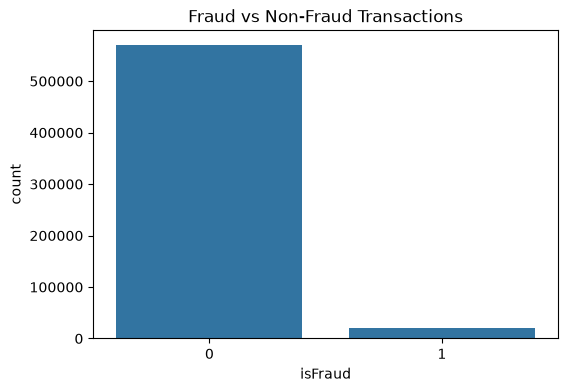

In [7]:
# visualize fraud distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="isFraud",
    data=train
)

plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

# Fraud Distribution Insight

The dataset exhibits severe class imbalance.

Most transactions are legitimate, while only a small percentage are fraudulent.

This reflects real-world banking and payment systems where fraudulent transactions are rare but financially significant.

Special handling techniques such as class weighting and advanced evaluation metrics will be required during model development.

In [8]:
# Product type fraud
product_fraud = pd.crosstab(
    train["ProductCD"],
    train["isFraud"],
    normalize="index"
) * 100

product_fraud

isFraud,0,1
ProductCD,,
C,88.312731,11.687269
H,95.233769,4.766231
R,96.217406,3.782594
S,94.100447,5.899553
W,97.960061,2.039939


In [9]:
# Card type fraud
card4_fraud = pd.crosstab(
    train["card4"],
    train["isFraud"],
    normalize="index"
) * 100

card4_fraud

isFraud,0,1
card4,,
american express,97.130163,2.869837
discover,92.271839,7.728161
mastercard,96.566905,3.433095
visa,96.524390,3.475610


In [10]:
# Email domain fraud
email_fraud = pd.crosstab(
    train["P_emaildomain"],
    train["isFraud"],
    normalize="index"
) * 100

email_fraud.sort_values(
    by=1,
    ascending=False
).head(10)

isFraud,0,1
P_emaildomain,,
protonmail.com,59.210526,40.789474
mail.com,81.037567,18.962433
outlook.es,86.986301,13.013699
aim.com,87.301587,12.698413
outlook.com,90.541601,9.458399
hotmail.es,93.442623,6.557377
live.com.mx,94.526035,5.473965
hotmail.com,94.704972,5.295028
gmail.com,95.645815,4.354185


In [11]:
# Device type fraud
device_fraud = pd.crosstab(
    train["DeviceType"],
    train["isFraud"],
    normalize="index"
) * 100

device_fraud

isFraud,0,1
DeviceType,,
desktop,93.478542,6.521458
mobile,89.833768,10.166232


In [12]:
# Transaction Amount by fraud
train.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


# Business Insights - Product Analysis

## Key Findings

- Product C recorded the highest fraud rate (11.69%).
- Product W recorded the lowest fraud rate (2.04%).
- Fraud behavior varies significantly across product categories.
- Product category can be considered an important predictive feature.

# Fraud Intelligence Findings

## Product Category

- Product C showed the highest fraud rate (11.69%).
- Product W showed the lowest fraud rate (2.04%).

## Card Type

- Discover cards experienced the highest fraud rate (7.73%).

## Email Domain

- ProtonMail recorded the highest fraud concentration (40.79%).
- Several less common domains exhibited elevated fraud risk.

## Device Type

- Mobile devices showed significantly higher fraud occurrence than desktop devices.

## Transaction Amount

- Fraudulent transactions tend to have higher transaction values.
- Transaction amount is a potentially important predictor.

In [13]:
# Top fraudulent email domains
fraud_domains = (
    train.groupby("P_emaildomain")["isFraud"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    * 100
)

fraud_domains

P_emaildomain
protonmail.com    40.789474
mail.com          18.962433
outlook.es        13.013699
aim.com           12.698413
outlook.com        9.458399
hotmail.es         6.557377
live.com.mx        5.473965
hotmail.com        5.295028
gmail.com          4.354185
yahoo.fr           3.496503
embarqmail.com     3.461538
mac.com            3.211009
icloud.com         3.143450
comcast.net        3.118661
charter.net        3.063725
Name: isFraud, dtype: float64

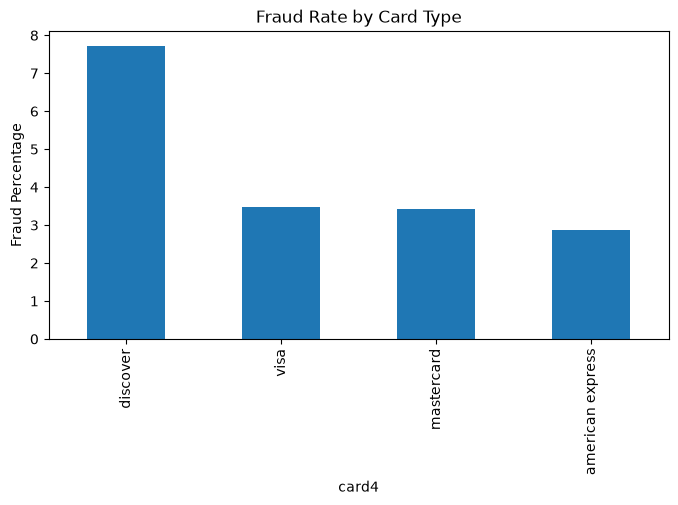

In [14]:
# Fraud by card network visualization
card_fraud = (
    train.groupby("card4")["isFraud"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

card_fraud.plot(kind="bar", figsize=(8,4))

plt.title("Fraud Rate by Card Type")
plt.ylabel("Fraud Percentage")

plt.show()

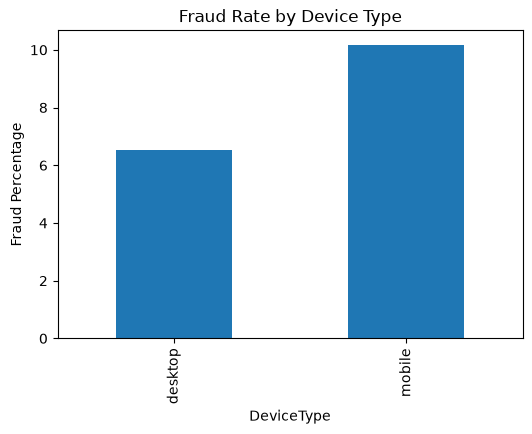

In [15]:
# Fraud by Device visualization
device_fraud = (
    train.groupby("DeviceType")["isFraud"]
    .mean()
    * 100
)

device_fraud.plot(kind="bar", figsize=(6,4))

plt.title("Fraud Rate by Device Type")
plt.ylabel("Fraud Percentage")

plt.show()

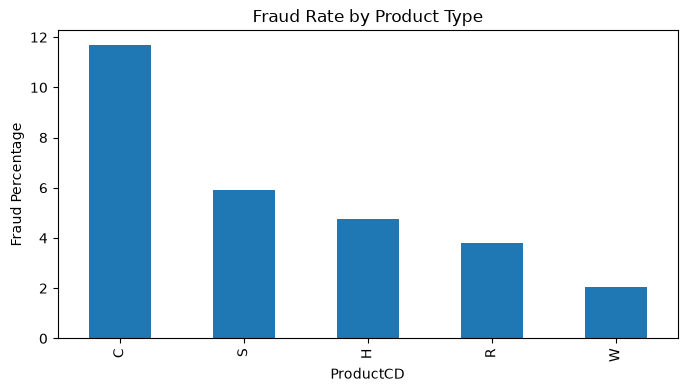

In [16]:
# fraud by product type visualization
product_fraud_rate = (
    train.groupby("ProductCD")["isFraud"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

product_fraud_rate.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Fraud Rate by Product Type")
plt.ylabel("Fraud Percentage")
plt.show()

In [21]:
# Top 20 most fraud prone email domains visualization
fraud_domains = (
    train.groupby("P_emaildomain")["isFraud"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    * 100
)

fraud_domains


P_emaildomain
protonmail.com    40.789474
mail.com          18.962433
outlook.es        13.013699
aim.com           12.698413
outlook.com        9.458399
hotmail.es         6.557377
live.com.mx        5.473965
hotmail.com        5.295028
gmail.com          4.354185
yahoo.fr           3.496503
Name: isFraud, dtype: float64

In [20]:
# Missing values percentage
missing_percent = (
    train.isnull().sum()
    / len(train)
) * 100

missing_percent = missing_percent.sort_values(
    ascending=False
)

missing_percent.head(10)

id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
dtype: float64

In [19]:
# Data types summary
train.dtypes.value_counts()

float64    399
str         31
int64        4
Name: count, dtype: int64

# Executive Fraud Insights

## Fraud Distribution
- Fraud transactions represent approximately 3.5% of total transactions.

## Product Risk
- Product C exhibits the highest fraud rate.

## Device Risk
- Mobile devices show higher fraud occurrence than desktops.

## Card Risk
- Discover cards exhibit elevated fraud activity.

## Email Risk
- Certain email domains show significantly higher fraud rates than the dataset average.

## Transaction Amount
- Fraudulent transactions generally involve larger transaction amounts.